# Limiar de similaridade 

As imagens do dataset foram construĩdas a partir de vĩdeos de colonoscopia, alguns frames vizinhos são do mesmo exame, então 
caso essas imagens caia em splits diferentes, o dado ficaria "iguais" do treino e teste, o que inflaria a métrica do modelo.

Portanto, devemos achar qual o limiar de similaridade para definir quais sao as imagens que vieram do mesmo frame ou instancia

In [39]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMAGENS = ROOT / "data/raw/Kvasir-SEG/images"


#carregar as imagens do dataset Kvasir-SEG
arquivos = sorted(IMAGENS.glob("*.jpg"))
print(f"{len(arquivos)} imagens em {IMAGENS.relative_to(ROOT)}")

1000 imagens em data/raw/Kvasir-SEG/images


In [40]:
lado = 128
# vamos redimensionar as imagens para miniaturas de 128x128 pixels, preservando a estrutura e mantendo a matriz pequena, assim tendo menos custo
T = np.stack([
    cv2.resize(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE), (lado, lado))
        .astype(np.float32).ravel()
    for f in arquivos
])
T -= T.mean(axis=1, keepdims=True)
T /= np.linalg.norm(T, axis=1, keepdims=True) + 1e-9


In [41]:
# vamos calcular a matriz de correlação entre as imagens, onde C[i, j] representa a correlação entre a imagem i e a imagem j
C = T @ T.T 
# aqui serve para identificar as imagens semelhantes usando a matriz de correlação, onde valores próximos de 1 indicam alta similaridade
iu = np.triu_indices(len(C), k=1)
pares = C[iu]
print(f"{len(pares):,} pares")

499,500 pares


In [42]:
# distribuicao de similaridade entre pares de imagens
percentis = [50, 90, 99, 99.9, 99.99]
valores = np.percentile(pares, percentis)

print(f"media   : {pares.mean():.3f}")
for p, v in zip(percentis, valores):
    print(f"p{p:<6}: {v:.3f}")
print(f"maximo  : {pares.max():.3f}")

media   : 0.376
p50    : 0.392
p90    : 0.638
p99    : 0.775
p99.9  : 0.845
p99.99 : 0.886
maximo  : 0.999


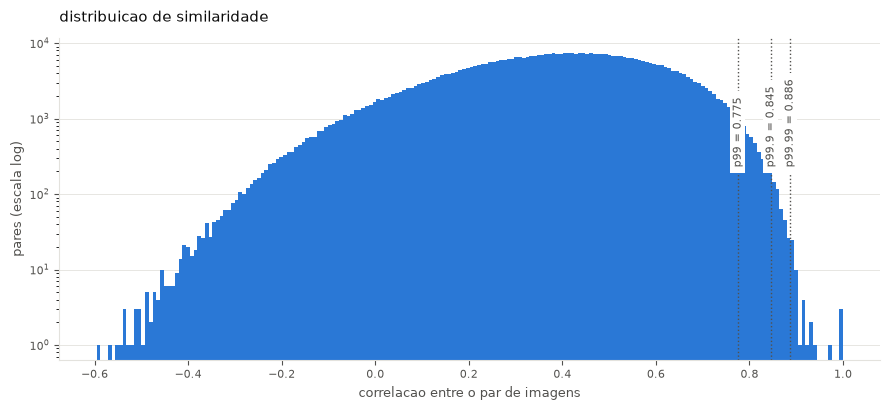

In [43]:
# vamso analisar a distribuicao de similaridade entre pares de imagens, para ver se ha duplicatas ou quase-duplicatas
AZUL, LARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, GRADE = "#0b0b0b", "#52514e", "#e3e2dd"

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(pares, bins=200, color=AZUL, linewidth=0)
ax.set_yscale("log") 

for pc, v in zip(percentis[2:], valores[2:]):
    ax.axvline(v, color=TINTA_2, linewidth=1, linestyle=":")
    ax.text(v, 200, f" p{pc} = {v:.3f} ", rotation=90, ha="center", va="bottom",
            fontsize=8, color=TINTA_2,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

ax.set_xlabel("correlacao entre o par de imagens", fontsize=9, color=TINTA_2)
ax.set_ylabel("pares (escala log)", fontsize=9, color=TINTA_2)
ax.set_title("distribuicao de similaridade",
             fontsize=11, color=TINTA, loc="left", pad=12)
ax.grid(axis="y", color=GRADE, linewidth=0.6)
ax.set_axisbelow(True)
for lado_ in ("top", "right"):
    ax.spines[lado_].set_visible(False)
for lado_ in ("left", "bottom"):
    ax.spines[lado_].set_color(GRADE)
ax.tick_params(colors=TINTA_2, labelsize=8)
plt.tight_layout()
plt.show()

In [44]:
# vamos agrupar as imagens por meio de arestas de similaridade, para que estejam no mesmo split
def agrupar(C, limiar):
    n = len(C)
    pai = list(range(n))

    def find(x):
        while pai[x] != x:
            pai[x] = pai[pai[x]]  
            x = pai[x]
        return x

    for i, j in zip(*np.where(np.triu(C > limiar, k=1))):
        a, b = find(i), find(j)
        if a != b:
            pai[a] = b
    _, rotulos = np.unique([find(i) for i in range(n)], return_inverse=True)
    return rotulos


limiares = np.round(np.arange(0.70, 0.991, 0.01), 2)
n_grupos, maior_grupo, n_agrupadas = [], [], []
for t in limiares:
    tam = np.bincount(agrupar(C, t))
    n_grupos.append(len(tam))
    maior_grupo.append(tam.max())
    n_agrupadas.append(tam[tam > 1].sum())

n_grupos = np.array(n_grupos); maior_grupo = np.array(maior_grupo)

O painel de baixo e o que decide. O maior grupo despenca de centenas de imagens para
poucas unidades num intervalo estreito: abaixo disso o encadeamento domina, acima disso
os grupos sao locais e o split continua viavel.

In [45]:
print(f"{'limiar':>7} {'grupos':>7} {'maior':>7} {'imgs agrupadas':>15}")
for t, g, m, a in zip(limiares, n_grupos, maior_grupo, n_agrupadas):
    if 0.84 <= t <= 0.96:
        print(f"{t:>7.2f} {g:>7d} {m:>7d} {a:>15d}")

 limiar  grupos   maior  imgs agrupadas
   0.84     710     206             309
   0.85     774     151             251
   0.86     841      57             193
   0.87     896      29             135
   0.88     937      13              94
   0.89     963      11              56
   0.90     983       3              30
   0.91     987       3              24
   0.92     992       3              15
   0.93     993       2              14
   0.94     995       2              10
   0.95     996       2               8
   0.96     996       2               8


In [46]:
# Para nao criar grupos muito grandes, vamos limitar o tamanho do maior grupo a 2% do dataset.
limite_tam = 0.02  
corte_duplicata = 0.95
# caso pares menor ou igual a 0.95, consideramos que são duplicatas certas, não apenas ruído de fundo.
# O p99.99 sobre todos os pares inclui essas duplicatas, inflando o piso que deveria medir apenas o ruído. Portanto, medimos o piso sem elas.
p9999 = float(np.percentile(pares[pares <= corte_duplicata], 99.99))

# a escolha nao pode depender de onde cortamos: conferimos a sensibilidade
print("sensibilidade do piso ao corte de duplicata:")
for corte in (1.00, 0.95, 0.92, 0.90):
    piso = float(np.percentile(pares[pares <= corte], 99.99))
    sel = (limiares > piso) & (maior_grupo <= limite_tam * len(arquivos))
    print(f"  pares <= {corte:.2f} ({(pares > corte).sum():>2} removidos): piso = {piso:.4f} -> limiar {limiares[sel][0]:.2f}")

ok = (limiares > p9999) & (maior_grupo <= limite_tam * len(arquivos))
LIMIAR = float(limiares[ok][0]) 

rotulos = agrupar(C, LIMIAR)
tam = np.bincount(rotulos)
print(f"\np99.99 da distribuicao nula : {p9999:.3f}")
print(f"limiar escolhido            : {LIMIAR:.2f}")
print(f"grupos                  : {len(tam)}")
print(f"maior grupo             : {tam.max()} imagens")
print(f"grupos com >1 imagem    : {(tam > 1).sum()}")
print(f"imagens em grupo        : {tam[tam > 1].sum()} de {len(arquivos)}")

sensibilidade do piso ao corte de duplicata:
  pares <= 1.00 ( 0 removidos): piso = 0.8860 -> limiar 0.89
  pares <= 0.95 ( 4 removidos): piso = 0.8851 -> limiar 0.89
  pares <= 0.92 ( 8 removidos): piso = 0.8839 -> limiar 0.89
  pares <= 0.90 (18 removidos): piso = 0.8803 -> limiar 0.89

p99.99 da distribuicao nula : 0.885
limiar escolhido            : 0.89
grupos                  : 963
maior grupo             : 11 imagens
grupos com >1 imagem    : 19
imagens em grupo        : 56 de 1000


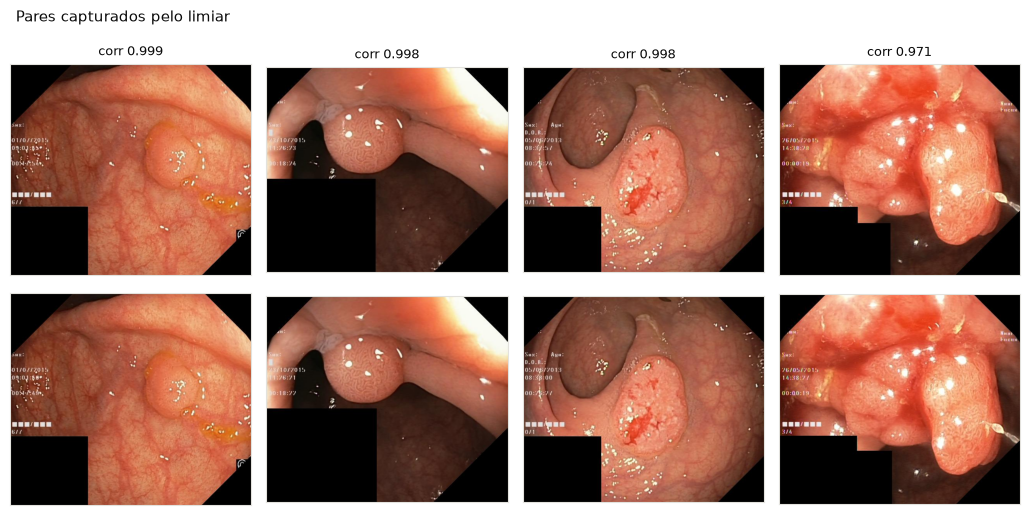

In [47]:
# selecionar os pares de imagens que passaram pelo limiar, para visualizacao
pares_idx = [(i, j) for i, j in zip(*np.where(np.triu(C > LIMIAR, k=1)))]
pares_idx.sort(key=lambda p: -C[p])

n = min(4, len(pares_idx))
fig, axes = plt.subplots(2, n, figsize=(2.6 * n, 5.4))
axes = np.atleast_2d(axes)
for col, (i, j) in enumerate(pares_idx[:n]):
    for linha, k in enumerate((i, j)):
        ax = axes[linha, col]
        ax.imshow(cv2.cvtColor(cv2.imread(str(arquivos[k])), cv2.COLOR_BGR2RGB))
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(GRADE)
    axes[0, col].set_title(f"corr {C[i, j]:.3f}", fontsize=9, color=TINTA)
fig.suptitle("Pares capturados pelo limiar",
             fontsize=11, color=TINTA, x=0.02, ha="left")
plt.tight_layout()
plt.show()